# Notebook di test

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.optimize import least_squares
from scipy.special import spherical_jn as jn
import emcee
import corner

import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
import utils.lib.granada_phases as granada
import utils.lib.auxiliary as aux
import utils.lib.lec_values as lec_values
from utils.lib.constants import *

In [2]:
#%matplotlib widget
#plt.close('all')

# Porting di plot_phase_shift

In [5]:
# Dalla teoria di fisica nucleare, sappiamo che la QCD è l'interazione tra quark, ma per via del loro confinamento i gradi di libertà
# sono i nucleoni. La forza forte tra nucleoni può essere intesa come l'equivalente delle forze di Van der Waals ma provenienti dalla QCD.
# La teoria esatta della QCD è molto poco pratica, quindi quello che facciamo è espandere la sua hamiltoniana in multipoli.
# In particolare, questa esperienza vuole valutare i coefficienti numerici dei primi termini di suddetto sviluppo.

# Per analizzare questi termini, la tecnica sperimentale di studiare l'interazione nucleone-nucleone è lo scattering.
# Come prima cosa, dunque, inizializziamo un'istanza dell'oggetto nn_studio, che al suo interno studia appunto lo scattering nucleone-nucleone:
nn = nn_studio.nn_studio(jmin=0,jmax=1,tzmin=0,tzmax=0,Np=20)
# Il numero quantico J è definito come J=L+S dove S è la somma dei due spin e L è il momento angolare relativo;
# il numero quantico Tz è la proiezione sull'asse z della somma dei due isospin forti.
# Nel nostro sviluppo, il valore minimo di J è prevedibilmente 0 mentre il suo valore massimo è limitato a 1;
# invece gli isospin dovranno necessariamente essere antiparalleli, nel senso che studiamo l'interazione protone-neutrone.

# Infine, Np è un parametro puramente computazionale. Determina la precisione del metodo numerico contenuto dentro l'oggetto.
# Più precisamente, indica la densità della mesh di integrazione dell'equazione di Lippman-Schwinger.


# Al suo interno, nn_studio associa un indice ad ogni possibile canale, nonché casistica di urto in base ai numeri quantici.
# Il metodo lookup_channel_idx restituisce l'indice corrispondente al canale <l' s j | l s j>, dove l' viene chiamato ll mentre
# s e j si presume non varino. Dopotutto, l'hamiltoniana dell'interazione forte mescola L ma non S né J.
_, selected_channel = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1)
print("For <l' s j | l s j> = <2 1 1 | 0 1 1> the channels are:\n\n", selected_channel)
print("\nwhich, as you may notice, are the four combinations of l' and l, and they all have the same channel index, it being 4.")
# Occhio quando chiedi i channel che i numeri quantici non sforino i limiti minimi e massimi imposti nel costruttore!
# In tal caso, non viene dato nessun errore, e il canale restituito è semplicemente una lista vuota.

# Stampare selected_channel in maniera più chiara è molto fastidioso per via di com'è costruito, lasciamo così.

For <l' s j || l s j> = <2 1 1 || 0 1 1> the channels are:

 [[{'l': 0, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 0, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}]]

which, as you may notice, are the four combinations of l' and l, and they all have the same channel index, it being 4.


computing T-matrices for
channel = [{'l': 0, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 0, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}]
Tlab = 1e-06 MeV
Tlab = 0.1 MeV
Tlab = 0.2 MeV
Tlab = 0.3 MeV
Tlab = 0.4 MeV
Tlab = 0.5 MeV
Tlab = 0.6 MeV
Tlab = 0.7 MeV
Tlab = 0.8 MeV
Tlab = 0.9 MeV
Tlab = 1.0 MeV
Tlab = 2 MeV
Tlab = 3 MeV
Tlab = 4 MeV
Tlab = 5 MeV
Tlab = 6 MeV
Tlab = 7 MeV
Tlab = 8 MeV
Tlab = 9 MeV
Tlab = 10 MeV
Tlab = 11 MeV
Tlab = 12 MeV
Tlab = 13 MeV
Tlab = 14 MeV
Tlab = 15 MeV
Tlab = 16 MeV
Tlab = 17 MeV
Tlab = 18 MeV
Tlab = 19 MeV
Tlab = 20 MeV
Tlab = 21 MeV
Tlab = 22 MeV
Tlab = 23 MeV
Tlab = 24 MeV
Tlab = 25 MeV
Tlab = 26 MeV
Tlab = 27 MeV
Tlab = 28 MeV
Tlab = 29 MeV
Tlab = 30 MeV
Tlab = 40 MeV
Tlab = 50 MeV
Tlab = 60 MeV
Tlab = 70 MeV
Tlab = 80 MeV
Tlab = 90 MeV
Tlab = 100 MeV


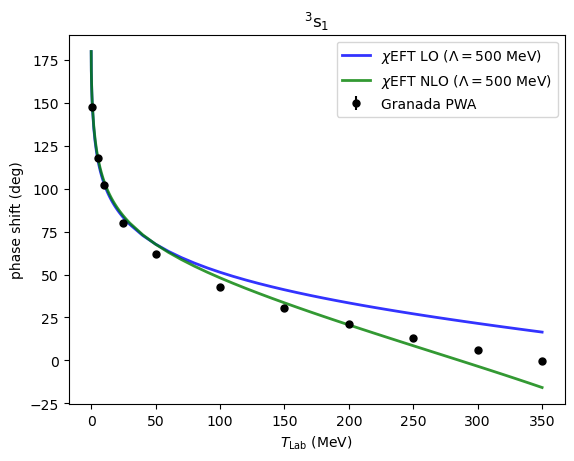

In [14]:
# Ora, cominciamo a definire tutte le cose che ci servono a far runnare la simulazione di scattering.

# Innanzitutto, ci servono i valori di energie cinetiche incidenti:
nn.Tlabs = [1e-6] + [x/10 for x in np.arange(1,11,1)]+[x for x in np.arange(2,31,1)] + [x for x in np.arange(40,360,10)]
# Nota che questa sintassi è equivalente ad una somma diretta di array, nel senso che vengono appended uno dopo l'altro.

# Poi, ci serve dare all'oggetto un potenziale di interazione. Quello lo prendiamo sempre da una delle librerie:
potential_lo = chiral_potential.two_nucleon_potential("LO",Lambda=500.0)
potential_nlo = chiral_potential.two_nucleon_potential("NLO",Lambda=500.0)
# LO e NLO si riferiscono a quale ordine dello sviluppo raggiungiamo. Ci aspettiamo che il caso LO sia meno preciso di quello NLO.
# Lambda invece è un soft cut-off sui valori di momento considerati: ci aspettiamo che la nostra teoria valga fino a circa 700MeV
# quindi, essendo il cut-off soft, imponiamo come limite massimo 500MeV.

# La simulazione dello scattering si basa sulla risoluzione numerica di un'equazione integrale. In quanto tale, vengono considerati tutti
# i possibili valori di momento, dallo zero all'infinito. Ovviamente all'infinito non ci possiamo arrivare, sia per non violare il regime
# teorico, sia perché ovviamente la macchina non può eseguire infinite operazioni.

# Passiamo uno dei suddetti potenziali all'oggetto:
nn.V = potential_lo

# Passiamo i parametri numerici al potenziale all'interno dell'oggetto:
nn.lecs = lec_values.lo_lecs
# Qui stiamo passando i valori tabulati che sappiamo essere veri, ma poi in pratica sarà su questi parametri che effettueremo l'analisi bayesiana.
# Nel caso LO i parametri sono due, mentre nel caso NLO i parametri sono in totale 9 (sarà poi da decidere se limitarsi ai primi 5 o farli tutti).
# Nota anche che nel caso NLO sono inclusi i due parametri di LO ma che assumeranno un nuovo valore.

# Un indizio datoci è che i parametri su cui fare inferenza sono completamente disaccoppiati, e quindi non è necessario fare inferenza su tutti
# quanti contemporaneamente.


# Runniamo la simulazione dell'esperimento di scattering:
nn.compute_Tmtx(selected_channel,verbose=True)
# Dobbiamo indicare il canale! Il punto è che noi consideriamo solo i primi termini dello sviluppo in multipoli, e questi coincidono
# con scegliere solo i casi in cui l assume valori 0 oppure 2. Questo coincide col canale che abbiamo stampato nella cella precedente.

# e salviamo i phase shift trovati:
delta_lo = nn.phase_shifts[0][:,0]

# Ripetiamo la simulazione anche con l'altro potenziale:
nn.V = potential_nlo
nn.lecs = lec_values.nlo_lecs
nn.compute_Tmtx(selected_channel,verbose=True)
delta_nlo = nn.phase_shifts[0][:,0]

# Salviamo e mettiamo da parte i valori sperimentali veri e propri, con cui faremo il confronto:
exp_phases = granada.delta_3S1
err_phases = granada.delta_3S1_errors

# Grafichiamo il tutto per vedere come i nostri due potenziali replicano o meno i dati sperimentali:
plt.errorbar(granada.Tlabs,exp_phases, yerr=err_phases,label = "Granada PWA", color="k",ls="none",marker="o",markersize=3.)
plt.plot(nn.Tlabs,delta_lo, label = r"$\chi$EFT LO ($\Lambda=500$ MeV)",color="blue",alpha=0.8,lw=2)
plt.plot(nn.Tlabs,delta_nlo, label = r"$\chi$EFT NLO ($\Lambda=500$ MeV)",color="green",alpha=0.8,lw=2)
plt.xlabel(r"$T_\mathrm{Lab}$ [MeV]")
plt.ylabel(r"phase shift [degrees]")
plt.title(r"$^3$S$_1$")
plt.legend()
plt.show()

# Porting di plot_potential

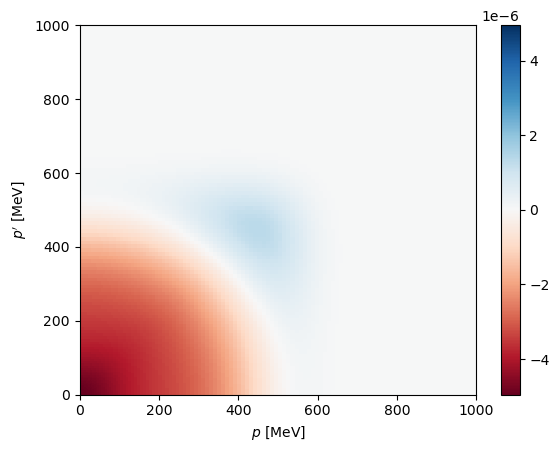

In [3]:
# Vogliamo studiare l'interazione nucleone-nucleone nel caso particolare del deutone.

# Come prima, inizializziamo nn_studio:
nn = nn_studio.nn_studio(jmin=0,jmax=1,tzmin=0,tzmax=0,Np=150,mesh_type="gauleg_finite")
# Il parametro mesh_type ha due sole opzioni: "gauleg_infinite" per prendere l'intervallo di momenti [0,+inf) e che è il default,
# oppure questo "gauleg_finite" che usiamo qui.
# In particolare la prima opzione è usata per studiare lo scattering, mentre la seconda per studiare gli stati legati, quale il deutone.

# Come prima, inizializziamo il potenziale:
potential = chiral_potential.two_nucleon_potential("NLO",Lambda=500.0)

# Come prima, passiamo il potenziale:
nn.V = potential

# Come prima, passiamo i valori nominali dei parametri del modello:
nn.lecs = lec_values.nlo_lecs


# Dalla teoria della fisica nucleare, sappiamo che il deutone non ha stati eccitati, essendo debolmente legato.
# I numeri quantici del ground state sono J=1, S=1, L=0,2. In particolare, la miscela è al 96% L=0 e al 4% L=2.
idx, selected_channel = nn.lookup_channel_idx(l=0,ll=0,s=1,j=1)
# L'esempio in cartella è per (l=0,ll=0,s=0,j=0), che è un canale possibile per lo scattering (o tra due nucleoni
# di un nucleo più grande) ma è proibito in realtà per il deutone.

# Quello che vogliamo concettualmente fare in primo luogo è tracciare il potenziale in funzione dei momenti dei due nucleoni.
# Ci aspettiamo che per bassi momenti i due nucleoni riescano a legarsi, mentre oltre a una certa soglia di energia cinetica totale dei due
# il sistema si sleghi.
# Questo potenziale lo disegneremo a mo' di heatmap: per farlo, dovremmo calcolare valori del potenziale
# per tante combinazioni di momenti, e quindi ottenere una matrice di valori. nn_studio fa proprio questo, e lo fa così:
_, potential_matrix = nn.setup_Vmtx(selected_channel[0])
# Va passato il primo elemento di selected_channel, anche se provando a stamparlo in realtà corrisponde comunque a tutti i casi.
# Il metodo qui usato in realtà restituisce prima la matrice di potenziale definita a blocchi per tutti i casi del canale, e po un array in cui
# ogni elemento coincide con la matrice di uno dei casi. Questo canale ha 4 casi di cui solo il primo coincide effettivamente con l=0, ll=0.
# La densità della matrice, e quindi la risoluzione della mappa, è data dal valore di Np che abbiamo deciso in precedenza.

# Procediamo a graficare:
mtx = potential_matrix[0] # prendiamo solo il primo canale su quattro
pp, p = np.meshgrid(nn.pmesh, nn.pmesh) # dove con pp indichiamo p'
z_min, z_max = -np.abs(mtx).max(), np.abs(mtx).max()

fig, ax = plt.subplots()
c = ax.pcolormesh(p, pp, mtx, cmap="RdBu", vmin=z_min, vmax=z_max)
fig.colorbar(c, ax=ax)
ax.set_xlabel(r"$p$ [MeV]")
ax.set_ylabel(r"$p'$ [MeV]")
plt.show()
# Nota che in realtà non è che il resto del grafico sia necessariamente bianco, è che col cut-off che introduciamo molti
# di quei valori non vengono calcolati nemmeno.

# Porting di simulate_deuteron

In [2]:
# Passiamo all'esperienza vera e propria.
# All'inizio, dobbiamo solo prendere spunto dagli esempi precedenti per capire come impostare il codice:

nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=100, mesh_type="gauleg_finite")
# jmax=1 perché il deutone ha J=1, tzmax=0 perché il deutone sono due nucleoni diversi, mesh_type finito perché il sistema è legato.

potential = chiral_potential.two_nucleon_potential("LO", Lambda=500.0)
# Studiamo prima il caso LO

nn.V = potential
nn.lecs = lec_values.lo_lecs

_, deuteron_channel = nn.lookup_channel_idx(l=0, ll=2, s=1, j=1)
# Essendo il deutoreone una miscela di L=0 e L=2, ci sono quattro possibili combinazioni di momenti angolati: S-S, S-D, D-S, D-D.
# s=1 e j=1 saranno fissati, questo poi è il caso particolare di uno delle due combinazioni miste.


# Calcoliamo la massa ridotta:
_, mu = nn.lab2rel(0, 0)
# il metodo lab2rel trasforma l'energia cinetica nel SR del laboratorio nell'energia cinetica del SR del COM.
# Il primo parametro è il valore dell'energia cinetica nel SR del laboratorio, il secondo parametro è tz.
# Il metodo restituisce il momento relativo e la massa ridotta.


# In realtà il numero totale di punti del mesh (intesa come dimensione della matrice) per il potenziale in blocchi sarà il doppio di Np,
# perché il canale ha 4 blocchi che occupano i quattro "quadranti" della matrice totale del potenziale.
N = 2 * (nn.Np)
# Inizializziamo dunque le matrici per i valori della hamiltoniana e dell'energia cinetica:
H = np.zeros((N, N))
T = np.zeros((N, N))
# La matrice del potenziale avrà infatti dimensione 2*Np x 2*Np per via della sua struttura a blocchi, e noi poi vorremo salvarci
# anche cinetica e hamiltoniana di tutti gli elementi/combinazioni.

# Creiamo adesso di fatto altre due matrici delle stesse dimensioni in cui però salviamo i punti e rispettivi pesi del mesh di nn_studio:
ww = np.hstack((nn.wmesh, nn.wmesh))
pp = np.hstack((nn.pmesh, nn.pmesh))
# hstack serve perché fare ad esempio ww = nn.wmesh, pp = nn.pmesh terrebbe conto di solo il primo blocco.


# Lasciamo che nn_studio costruisca la matrice a blocchi del potenziale:
V = nn.setup_Vmtx(deuteron_channel[0])[0]
# e riempiamo ora anche la matrice cinetica e la matrice hamiltoniana:
for i, p_bra in enumerate(pp):
    for j, p_ket in enumerate(pp):
        Tij = 0
        if i == j: # solo i termini diagonali della matrice cinetica sono diversi da zero
            Tij = p_bra ** 2 / (2 * mu)
            T[i][j] = Tij
        # Inoltre, normalizziamo il potenziale con i momenti e con i pesi in quadratura:
        V[i][j] = V[i][j] * p_bra * p_ket * np.sqrt(ww[i] * ww[j])
        # Questo è uno step standard: è necessario farlo quando si passa dall'integrale continuo alla mesh discreta.
        # Se non venisse fatto, l'hermitiana risultante non verrebbe fuori hermitiana!
        # Il potenziale di prima era corretto, ma pensa a questo come un semplice riscalamento per ottenere un potenziale efficace.
H = T + V


# Risolviamo l'equazione di Schrödinger, ossia troviamo autovalori e autovettori dell'hamiltoniana da noi costruita:
eigvals, eigvecs = linalg.eigh(H)
s = np.argsort(eigvals)  # ordiniamo gli autovalori
E = eigvals[s[0]] # e prendiamo il più basso, ossia il ground state

# Ci salviamo anche la funzione d'onda del ground state, nonché l'inequivoca funzione d'onda del deutone:
phi_gs = eigvecs[:, s[0]]

# Stampiamo l'energia del ground state da noi calcolata:
print(f"\nEnergia nominale del deutone in approssimazione LO: {E:.3f} MeV\n")


Energia nominale del deutone in approssimazione LO: -1.928 MeV



### Ma perché normalizzare il potenziale in quel modo?
Apriamo una parentesi teorica per spiegarlo come si deve. In questo codice noi lavoriamo sempre nello spazio dei momenti, quindi ci sono delle accortezze in più che dobbiamo prendere a cui non siamo abituati. Per iniziare, l'equazione di Schrödinger per uno stato stazionario nello spazio dei momenti diventa:
$$\frac{p^2}{2\mu} \psi(p) + \int_0^{+\infty} V(p,p')\, \psi(p')\, p'\,^2 dp' = E\, \psi(p) $$
dove in particolare il potenziale agisce dentro un integrale. Per risolvere questo integrale numericamente, lo discretizziamo passando ad una cosìddetta "mesh":
$$\int f(p')\, dp'\ \longmapsto\ \sum_j^{(\infty)} w_j\, f(p_j) $$
che altro non è che l'integrale di Riemann ma con un peso annesso a ciascun contributo.
Facendo questo passaggio, l'equazione di stato diventerebbe:
$$\frac{p_i^2}{2\mu} \psi(p) + \sum_j w_j\, p_j^2\, V(p_i,p_j)\, \psi(p_j) = E\, \psi(p_i)  $$
ma notiamo che così il potenziale efficace $K_{ij} \equiv w_j\, p_j^2\, V(p,p')$ non sarebbe simmetrico, e quindi non sarebbe hermitiano!

Per recuperare un potenziale efficace simmetrico, il procedimento standard è riscalare le funzioni d'onda nel seguente modo:
$$\varphi(p_i) = \sqrt{w_i}\, p_i\, \psi(p_i)\ \,. $$
Verifichiamo cosa otteniamo partendo dall'equazione di Schrödinger e facendo sia questo riscalamento che il passaggio alla mesh:
$$\frac{p_i^2}{2\mu}\, \frac{\varphi(p_i)}{\sqrt{w_i}\, p_i} + \sum_j w_j\, p_j^2\, V(p_i,p_j)\, \frac{\varphi(p_j)}{\sqrt{w_j}\, p_j} = E\, \frac{\varphi(p_i)}{\sqrt{w_i}\, p_i} $$
$$\Longrightarrow\ \ \frac{p_i^2}{2\mu} \varphi(p_i) + \sum_j \sqrt{w_i} \sqrt{w_j}\, p_i\, p_j\, V(p_i,p_j)\, \varphi(p_j) = E\, \varphi(p_i)$$
$$\Longrightarrow\ \ K_{ij} \equiv \sqrt{w_i\, w_j}\, p_i\, p_j V(p_i,p_j)$$
che stavolta è simmetrico!

Nota, però, che le $\varphi$ sono comunque solo un ausilio matematico. Gli autovalori dell'energia sono quelli giusti (nelle equazioni rimangono invariati), ma quando calcoleremo gli autovettori saranno quelli associati al potenziale efficace e non al potenziale fisico. Quindi, per tornare ai vettori fisici $\psi$, dovremo riapplicare lo riscalamento inverso.

# Esperienza 4

In [3]:
# Vogliamo adesso fare una stima, sempre in approssimazione LO, di quali siano le percentuali della miscela S e D.
# Per farlo, ci ricordiamo che abbiamo già salvato la funzione d'onda del deutone, ma poi ci ricordiamo anche di altre due cose:
# la prima è che si tratta dell'autovettore associato al potenziale efficace invece che a quello fisico, e la seconda è che per costruzione
# quello è l'autovettore della matrice hamiltoniana che aveva dimensione 2Np x 2Np.

# Come prima cosa, applichiamo il riscalamento inverso per tornare alla funziona d'onda fisica, sempre nello spazio dei momenti:
psi_gs = phi_gs / (pp * np.sqrt(ww))
# Nota che l'autovettore non-fisico phi è stato calcolato con la norma euclidea, quindi quello era effettivamente normalizzato a 1,
# ma ora l'autovettore fisico psi NON è normalizzato ad 1 ed è corretto così, infatti:
norm = np.sqrt(np.sum(ww * pp**2 * psi_gs**2)) # QUESTA è la norma non-euclidea del vettore fisico, ed è questa che vale 1!
print(f"La norma del vettore fisico è {norm}")

# Poi notiamo che l'autovettore è diviso in due blocchi, ciascuno lungo Np elementi: il primo blocco corrisponde allo stato S, il secondo al D.
u_tilde = phi_gs[:nn.Np]
w_tilde = phi_gs[nn.Np:]
# Salviamo questi nonostante siano i vettori ausiliari piuttosto che quelli fisici. Tra poco ci ritorneranno utili.
u_p = psi_gs[:nn.Np]
w_p = psi_gs[nn.Np:]
# Queste due sono invece le funzioni d'onda ridotte fisiche!
# E sono già normalizzate se usiamo la norma giusta, infatti:
norm = np.sum(nn.wmesh * nn.pmesh**2 * (u_p**2 + w_p**2))
print(f"La norma delle funzioni d'onda fisiche ridotte è {norm}")

# Per calcolare le probabilità, saremmo tentati di semplicemente calcolare il modulo quadro di ciascun blocco.
# Questo sarebbe corretto se la norma fosse quella euclidea, ma abbiamo detto che i vettori fisici non obbediscono più a quella di norma.
# Quindi, o usiamo la norma giusta che è la stessa che abbiamo calcolato prima, oppure calcoliamo le probabilità sul vettore non-fisico in primo luogo:
P_S = np.sum(u_tilde**2)
P_D = np.sum(w_tilde**2)
# Mentre col vettore fisico avremmo dovuto ad esempio fare P_S = np.sum(nn.wmesh * nn.pmesh**2 * u_p**2) e avrebbe dato lo stesso risultato.

print(f"\nPercentuale di onda S: {P_S * 100:.2f}%")
print(f"Percentuale di onda D: {P_D * 100:.2f}%\n")

La norma del vettore fisico è 1.0000000000000004
La norma delle funzioni d'onda fisiche ridotte è 1.0000000000000007

Percentuale di onda S: 92.12%
Percentuale di onda D: 7.88%



### Quadrupolo elettrico
La formula esplicita e completa del quadrupolo elettrico del deutone nello spazio delle posizioni è la seguente:
$$Q = \frac{1}{20} \int_0^\infty w(r) \left[ \sqrt{8}\, u(r) - w(r) \right]\, r^2 dr$$
dove $u(r)$ è la funzione d'onda associata a L=0 mentre $w(r)$ è la funzione d'onda associata a L=2.

La formula sopra è però nello spazio delle posizioni. Noi abbiamo i vettori fisici $\psi$ nello spazio dei momenti e in particolare abbiamo le funzioni d'onda $u(p)$ associata a $L=0$ e $w(p)$ associata a $L=2$; queste andranno trasformate nello spazio delle posizioni, e le formule per farlo sono
$$u(r) = \sqrt{\frac{2}{\pi}} \int_0^{\infty} j_0(pr)\, u(p)\, p^2 dp \ \,,$$
$$w(r) = \sqrt{\frac{2}{\pi}} \int_0^{\infty} j_2(pr)\, w(p)\, p^2 dp \ \,$$
dove le $j_L$ sono le funzioni di Bessel sferiche. Questa trasformata è un integrale esattamente analogo a quello che abbiamo risolto prima, e infatti lo risolveremo nello stesso modo: passando ad una mesh e riscalando le funzioni d'onda. Siccome sia la mesh che le funzioni d'onda riscalate le abbiamo già costruite, semplicemente le riutilizzeremo.

Una volta ottenute $u(r)$ e $w(r)$, il calcolo del quadrupolo elettrico sarà, come sempre, risolto usando una mesh. Le librerie a nostra disposizione non operano nello spazio delle posizioni, quindi stavolta la mesh dovremo costruircela a mano.
Per semplificarci la vita, useremo una mesh lineare, i cui pesi sono tutti uguali e varranno $dr$. Nota, inoltre, che nello spazio delle posizioni non sarà necessario riscalare le funzioni d'onda.

In [4]:
# Tentativo di fare il calcolo direttamente in momentum-space:

from scipy.interpolate import CubicSpline

du = np.gradient(u_p, nn.pmesh, edge_order=2)
dw = np.gradient(w_p, nn.pmesh, edge_order=2)
#splined_w = CubicSpline(nn.pmesh, w_p)
#dw = splined_w.derivative()(nn.pmesh)

Q_integrand = np.sqrt(8) * (nn.pmesh**2 * du * dw + 3 * u_p * w_p) - (nn.pmesh**2 * dw**2 + 6 * w_p**2) # è questa la formula??? ########

Q = (1/20) * np.sum(nn.wmesh * Q_integrand)
Q *= hbarc**2
print(Q) # 0.17

0.17600695552224752


In [6]:
# Passiamo al calcolo del quadrupolo elettrico, in approssimazione di LO.

# Ricordiamoci dalla libreria fornitaci che hbarc è la costante di conversione fondamentale tra energia e distanza: hbarc = 197.3 MeV fm.
# Il valore sperimentale del quadrupolo elettrico, con cui faremo il confronto, è:
Q_obs = 0.286 # fm^2

# La prima cosa da fare è costruire le funzioni d'onda nello spazio delle posizioni.
# È vero che dobbiamo risolvere l'integrale della trasformata, ma prima ci serve una mesh per r in cui salvare i risultati in primo luogo:
Np = 1000 # Indicherà quanto è fitta la mesh
r_mesh = np.linspace(0.0, 30.0, Np, endpoint=False) # Costruiamo la mesh più semplice possibile, ossia lineare
dr = r_mesh[1] - r_mesh[0] # Il peso in una mesh lineare è dato semplicemente dallo step della mesh
u_r = np.zeros_like(r_mesh)
w_r = np.zeros_like(r_mesh)


# Ora che abbiamo vettori in cui salvare i risultati, possiamo svolgere la trasformata:
for i, r in enumerate(r_mesh):
    
    # Costruiamo le funzioni di Bessel, ricordandoci di convertire i momenti da MeV a fm^-1:
    j0 = jn(0, (nn.pmesh / hbarc) * r)
    j2 = jn(2, (nn.pmesh / hbarc) * r)
    # Ricorda che per com'è costruito pp, i punti (e anche i pesi) nei vari blocchi del potenziale sono perfettamente replicati.

    # Risolviamo l'integrale:
    u_r[i] = (2/np.pi) * np.sum(np.sqrt(nn.wmesh) * (nn.pmesh / hbarc) * j0 * u_tilde)
    w_r[i] = (2/np.pi) * np.sum(np.sqrt(nn.wmesh) * (nn.pmesh / hbarc) * j2 * w_tilde)


# Ci assicuriamo che il risultato da noi ottenuto sia effettivamente normalizzato.
# Tecnicamente anche qui riconduciamo l'integrale ad una mesh, quindi ci ricordiamo di aggiungere il peso nella norma:
norm = np.sqrt(np.sum((u_r**2 + w_r**2) * dr))
print(f"La norma delle funzioni d'onda radiali ridotte è {norm}")

# Un'ulteriore accortezza è che risolvere gli integrali numericamente fornisce sì le funzioni d'onda giuste ma a meno di una fase globale.
# In pratica, siccome per costruzione le nostre funzioni d'onda sono reali, potrebbe essere che il risultato abbia il segno sbagliato.
# Per convenzione, la u_r si prende positiva, e la w_r si prende affinché il quadrupolo risultante sia positivo:
if u_r[np.argmax(np.abs(u_r))] < 0:
    u_r *= -1
if np.sum(r_mesh**2 * u_r * w_r) < 0:
    w_r *= -1

# E infine il calcolo del quadrupolo si fa in un colpo solo:
Q_integrand = w_r * (np.sqrt(8) * u_r - w_r) * r_mesh**2
Q = (1/np.sqrt(20)) * np.sum(dr * Q_integrand)
print(f"\nQuadrupolo elettrico del deutone in approssimazione LO: {Q:.3f} fm^2\t(valore sperimentale: {Q_obs:.3f} fm^2)")

La norma delle funzioni d'onda radiali ridotte è 7.297883832889407

Quadrupolo elettrico del deutone in approssimazione LO: 17.019 fm^2	(valore sperimentale: 0.286 fm^2)
